# LSTM Sentiment analysis on train.tsv , test.tsv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/10.S RNN & LSTM/RNN - LSTM - GRU

/content/drive/MyDrive/Machine learning 2024/Notebooks - ANN - DNN/10.S RNN & LSTM/RNN - LSTM - GRU


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding, LSTM, GlobalMaxPooling1D, SpatialDropout1D

We`ll perform sentiment analysis on a corpus of movie reviews. We’re asked to label each phrase on a scale of zero to four. The sentiment corresponding to each of the labels are:


0: negative

1: somewhat negative

2: neutral

3: somewhat positive

4: positive


In [ ]:
df_train = pd.read_csv('train.tsv', sep='\t')
print('train set: {0}'.format(df_train.shape))
df_train.head(10)

train set: (156060, 4)


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2
5,6,1,of escapades demonstrating the adage that what...,2
6,7,1,of,2
7,8,1,escapades demonstrating the adage that what is...,2
8,9,1,escapades,2
9,10,1,demonstrating the adage that what is good for ...,2


In [ ]:
df_test = pd.read_csv('test.tsv', sep='\t')
print('test set: {0}'.format(df_test.shape))
df_test.head(10)

test set: (66292, 3)


,PhraseId,SentenceId,Phrase
0,156061,8545,An intermittently pleasing but mostly routine ...
1,156062,8545,An intermittently pleasing but mostly routine ...
2,156063,8545,An
3,156064,8545,intermittently pleasing but mostly routine effort
4,156065,8545,intermittently pleasing but mostly routine
5,156066,8545,intermittently pleasing but
6,156067,8545,intermittently pleasing
7,156068,8545,intermittently
8,156069,8545,pleasing
9,156070,8545,but


In [ ]:
replace_list = {r"i'm": 'i am',
                r"'re": ' are',
                r"let’s": 'let us',
                r"'s":  ' is',
                r"'ve": ' have',
                r"can't": 'can not',
                r"cannot": 'can not',
                r"shan’t": 'shall not',
                r"n't": ' not',
                r"'d": ' would',
                r"'ll": ' will',
                r"'scuse": 'excuse',
                ',': ' ,',
                '.': ' .',
                '!': ' !',
                '?': ' ?',
                '\s+': ' '}
def clean_text(text):
    text = text.lower()
    for s in replace_list:
        text = text.replace(s, replace_list[s])
    text = ' '.join(text.split())
    return text

In [ ]:
X_train = df_train['Phrase'].apply(lambda p: clean_text(p))

max phrase len: 53


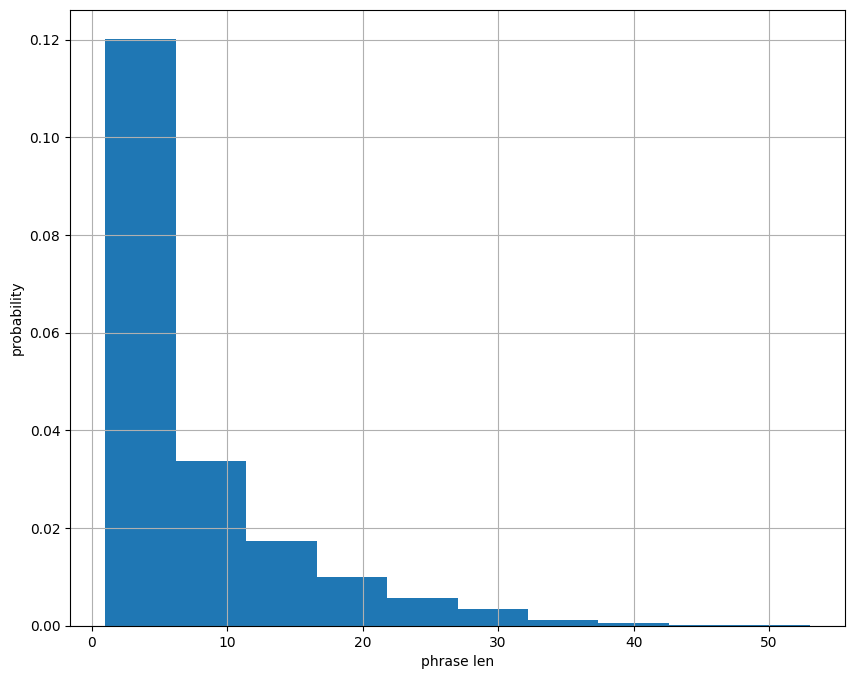

In [ ]:
phrase_len = X_train.apply(lambda p: len(p.split(' ')))
max_phrase_len = phrase_len.max()
print('max phrase len: {0}'.format(max_phrase_len))
plt.figure(figsize = (10, 8))
plt.hist(phrase_len, density = True)
plt.xlabel('phrase len')
plt.ylabel('probability')
plt.grid()

In [ ]:
y_train = df_train['Sentiment']

In [ ]:
max_words = 8192
tokenizer = Tokenizer(
    num_words = max_words,
    filters = '"#$%&()*+-/:;<=>@[\]^_`{|}~'
)
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_train = pad_sequences(X_train, maxlen = max_phrase_len)
y_train = to_categorical(y_train) # one hot encoding

In [ ]:
batch_size = 512
epochs = 8

In [ ]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim = max_words, output_dim = 256, input_length = max_phrase_len))
model_lstm.add(SpatialDropout1D(0.3))
model_lstm.add(LSTM(256))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(256))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(5, activation = 'softmax'))

model_lstm.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

SpatialDropout1D: Instead of dropping individual units, it drops entire 1D feature maps across all timesteps (i.e., drops out entire word embeddings or features at the same time across the sequence). This helps maintain the structure of sequences and is particularly effective when dealing with 1D data like text or time series

In [ ]:
history = model_lstm.fit(
    X_train,
    y_train,
    validation_split = 0.1,
    epochs = 10,
    batch_size = 32
)

Epoch 1/10
4390/4390 [==============================] - 76s 17ms/step - loss: 0.6431 - accuracy: 0.7329 - val_loss: 1.1463 - val_accuracy: 0.5899
Epoch 2/10
4390/4390 [==============================] - 76s 17ms/step - loss: 0.6091 - accuracy: 0.7477 - val_loss: 1.1839 - val_accuracy: 0.5891
Epoch 3/10
4390/4390 [==============================] - 78s 18ms/step - loss: 0.5872 - accuracy: 0.7559 - val_loss: 1.1945 - val_accuracy: 0.5862
Epoch 4/10
4390/4390 [==============================] - 85s 19ms/step - loss: 0.5645 - accuracy: 0.7651 - val_loss: 1.2222 - val_accuracy: 0.5865
Epoch 5/10
4390/4390 [==============================] - 154s 35ms/step - loss: 0.5453 - accuracy: 0.7728 - val_loss: 1.2920 - val_accuracy: 0.5811
Epoch 6/10
4390/4390 [==============================] - 158s 36ms/step - loss: 0.5244 - accuracy: 0.7816 - val_loss: 1.3270 - val_accuracy: 0.5758
Epoch 7/10
4390/4390 [==============================] - 162s 37ms/step - loss: 0.5046 - accuracy: 0.7901 - val_loss: 1.361

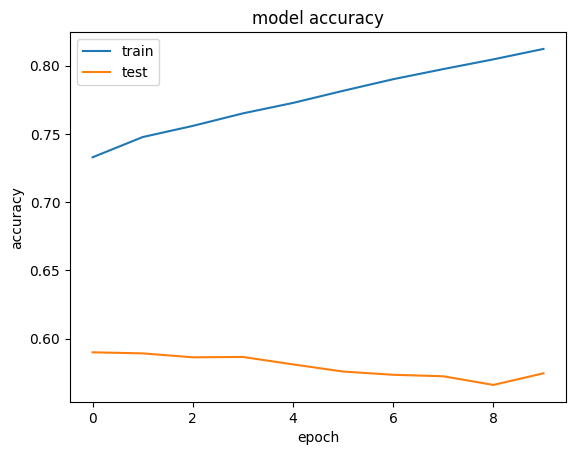

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

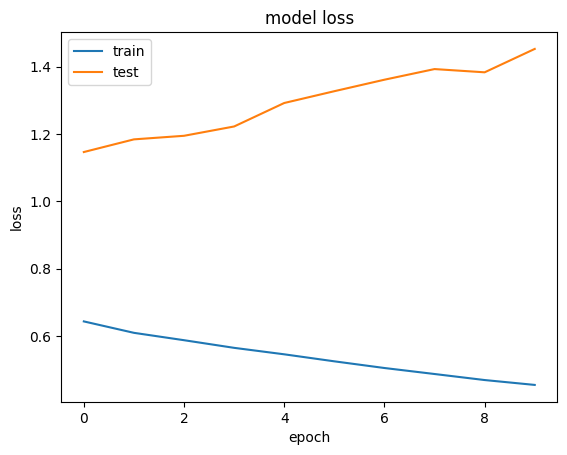

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
